# K3s Autoscaler - Exploratory Data Analysis

This notebook explores historical metrics and scaling decisions to identify patterns for predictive scaling.

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load Data

In [2]:
# Load extracted data
metrics_df = pd.read_csv('../data/metrics_samples.csv', parse_dates=['timestamp'])
history_df = pd.read_csv('../data/scaling_history.csv', parse_dates=['timestamp'])

print(f"Metrics samples: {len(metrics_df)} records")
print(f"Scaling history: {len(history_df)} decisions")
print(f"\nMetrics date range: {metrics_df['timestamp'].min()} to {metrics_df['timestamp'].max()}")
print(f"History date range: {history_df['timestamp'].min()} to {history_df['timestamp'].max()}")

Metrics samples: 21601 records
Scaling history: 1089 decisions

Metrics date range: 2025-12-25 19:25:12.481209+00:00 to 2026-01-24 19:25:12.481209+00:00
History date range: 2025-12-25 19:25:12.481209+00:00 to 2026-01-24 19:25:12.481209+00:00


## 2. Data Overview

In [3]:
# Display first few rows
print("Metrics Samples:")
display(metrics_df.head())

print("\nScaling History:")
display(history_df.head())

Metrics Samples:


,timestamp,cpu_percent,memory_percent,pending_pods,worker_count,ready_nodes,total_nodes
0,2025-12-25 19:25:12.481209+00:00,50.163063,27.614159,1,2,2,3
1,2025-12-25 19:27:12.481209+00:00,46.988170,32.172415,0,2,2,3
2,2025-12-25 19:29:12.481209+00:00,50.917935,30.412408,1,2,2,3
3,2025-12-25 19:31:12.481209+00:00,55.294641,30.419080,1,2,2,3
4,2025-12-25 19:33:12.481209+00:00,46.508725,31.389696,0,2,2,3



Scaling History:


,timestamp,decision_id,action,cpu_percent,memory_percent,pending_pods,current_nodes,target_nodes,reason
0,2025-12-25 19:25:12.481209+00:00,decision-0,SCALE_UP,50.163063,27.614159,1,2,3,CPU 50.2% >= 70% or Pending pods 1
1,2025-12-25 19:35:12.481209+00:00,decision-5,SCALE_UP,46.508807,29.020286,2,3,4,CPU 46.5% >= 70% or Pending pods 2
2,2025-12-25 19:55:12.481209+00:00,decision-15,SCALE_UP,44.868054,32.440668,1,4,5,CPU 44.9% >= 70% or Pending pods 1
3,2025-12-25 20:05:12.481209+00:00,decision-20,SCALE_UP,53.009727,29.057250,1,5,6,CPU 53.0% >= 70% or Pending pods 1
4,2025-12-25 20:35:12.481209+00:00,decision-35,SCALE_UP,39.577265,24.142983,1,6,7,CPU 39.6% >= 70% or Pending pods 1


In [4]:
# Summary statistics
print("Metrics Summary Statistics:")
display(metrics_df.describe())

print("\nScaling Actions Distribution:")
print(history_df['action'].value_counts())

Metrics Summary Statistics:


,cpu_percent,memory_percent,pending_pods,worker_count,ready_nodes,total_nodes
count,21601.000000,21601.000000,21601.000000,21601.000000,21601.000000,21601.000000
mean,54.693203,33.881238,0.326976,2.570390,2.554002,3.570390
std,20.982229,11.314813,1.068869,0.962568,0.950859,0.962568
min,5.000000,20.000000,0.000000,2.000000,2.000000,3.000000
25%,39.218138,23.310225,0.000000,2.000000,2.000000,3.000000
50%,54.507484,32.745273,0.000000,2.000000,2.000000,3.000000
75%,69.606630,42.190748,0.000000,3.000000,3.000000,4.000000
max,95.000000,65.357576,14.000000,5.000000,5.000000,6.000000



Scaling Actions Distribution:
action
SCALE_UP      545
SCALE_DOWN    544
Name: count, dtype: int64


## 3. Time-Series Patterns

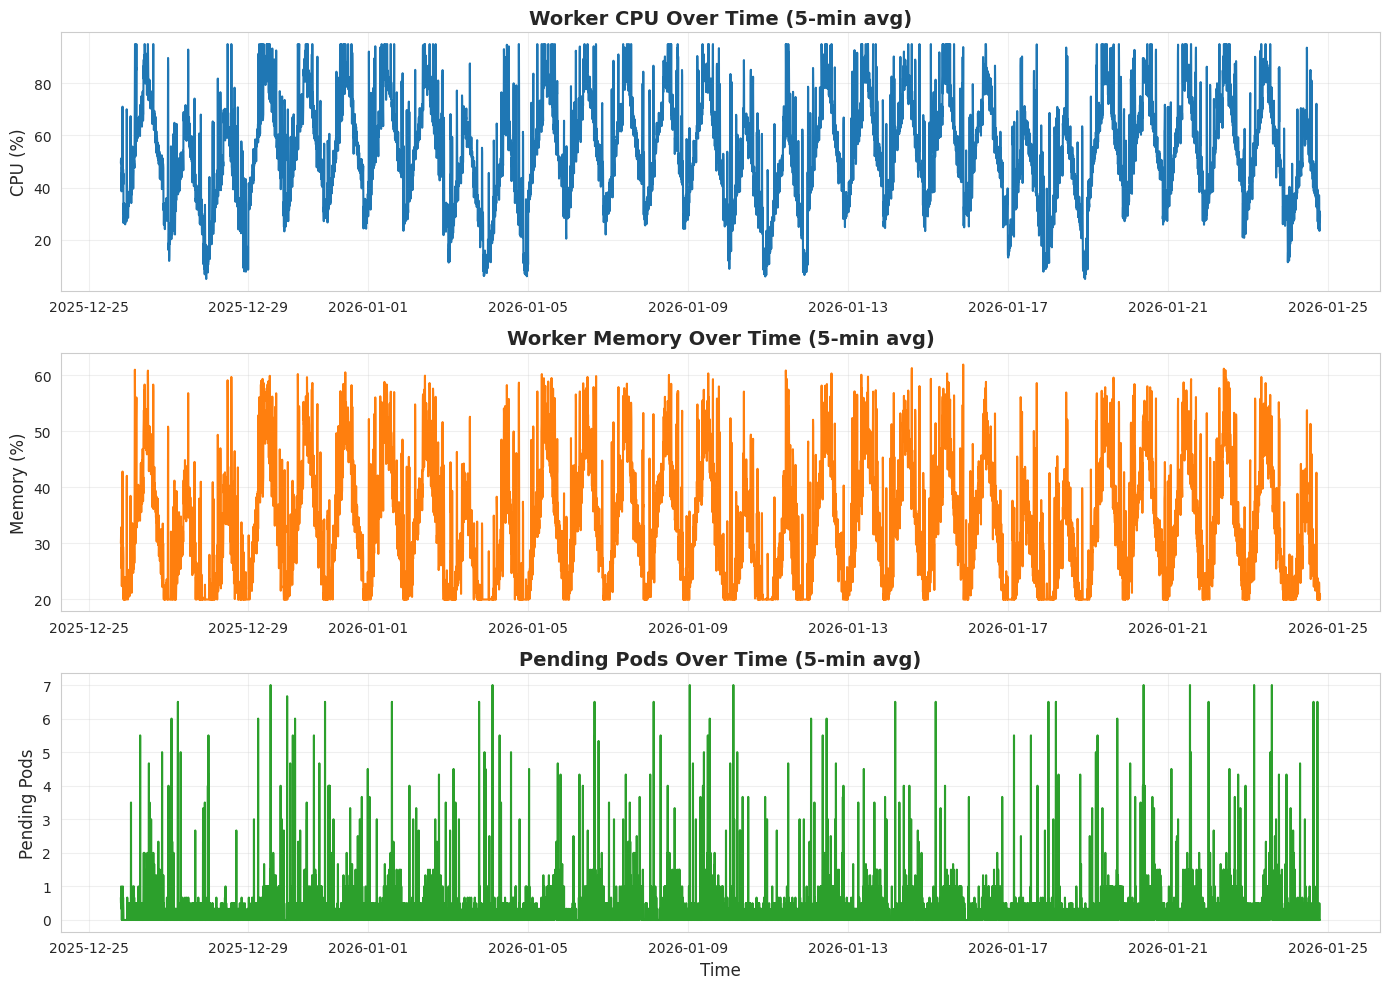

In [6]:
# Set timestamp as index for time-series analysis
metrics_ts = metrics_df.set_index('timestamp').sort_index()

# Resample to 5-minute intervals for smoother visualization
metrics_5min = metrics_ts.resample('5min').mean()

# Plot CPU over time
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# CPU
axes[0].plot(metrics_5min.index, metrics_5min['cpu_percent'], color='#1f77b4')
axes[0].set_title('Worker CPU Over Time (5-min avg)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('CPU (%)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Memory
axes[1].plot(metrics_5min.index, metrics_5min['memory_percent'], color='#ff7f0e')
axes[1].set_title('Worker Memory Over Time (5-min avg)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Memory (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Pending Pods
axes[2].plot(metrics_5min.index, metrics_5min['pending_pods'], color='#2ca02c')
axes[2].set_title('Pending Pods Over Time (5-min avg)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Pending Pods', fontsize=12)
axes[2].set_xlabel('Time', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Daily/Weekly Seasonality

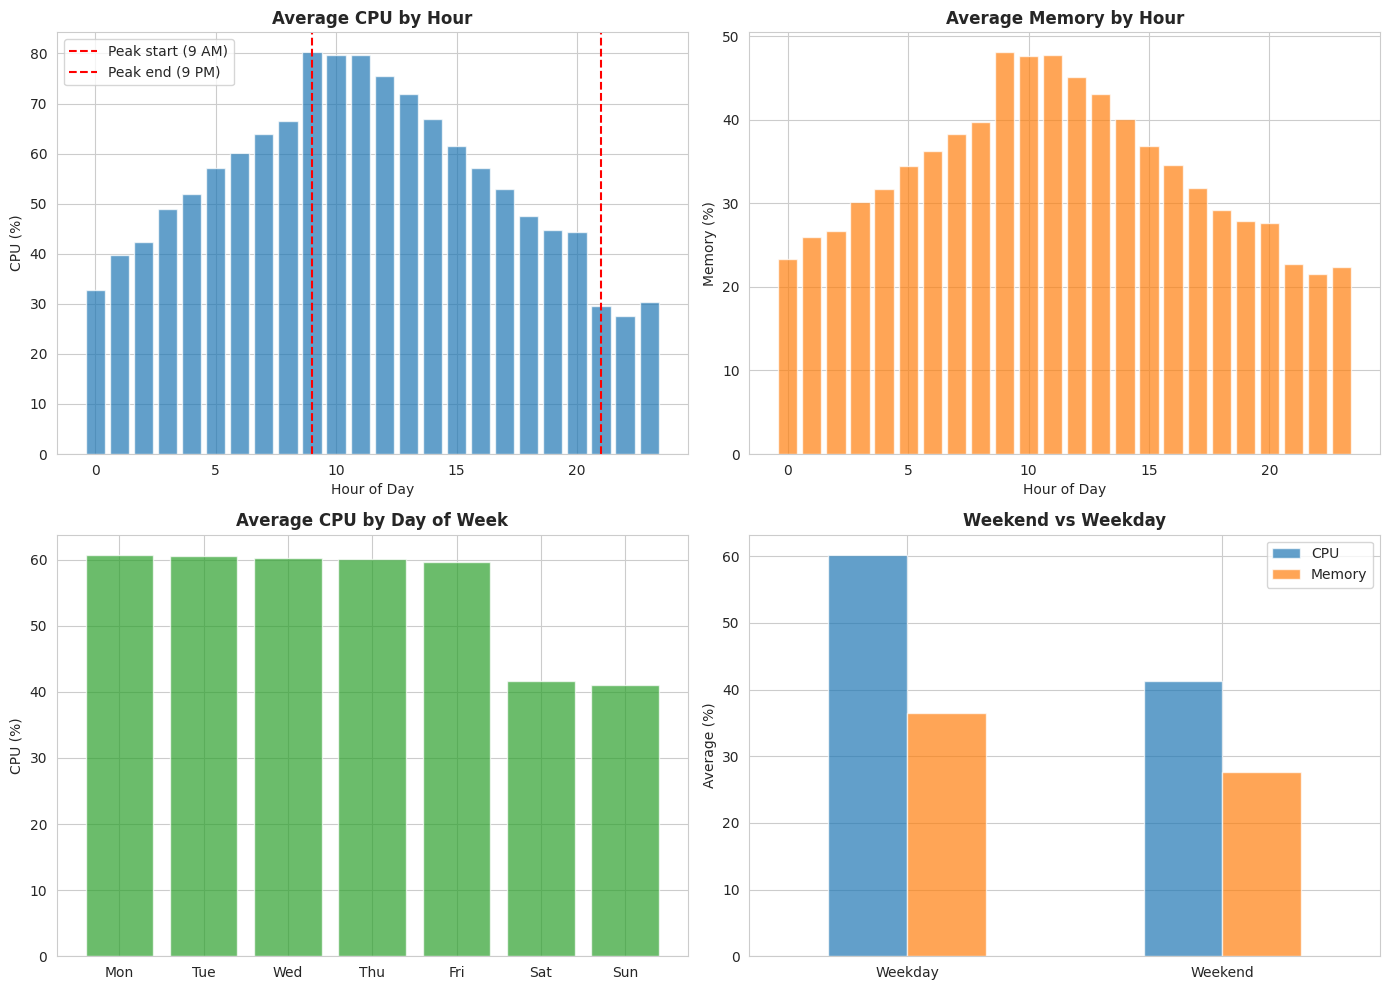


SEASONALITY INSIGHTS
Peak hour CPU (9AM-9PM): 60.9%
Off-peak CPU (9PM-9AM): 47.4%
Weekday CPU: 60.2%
Weekend CPU: 41.4%


In [7]:
# Extract time features
metrics_df['hour'] = metrics_df['timestamp'].dt.hour
metrics_df['day_of_week'] = metrics_df['timestamp'].dt.dayofweek
metrics_df['is_weekend'] = metrics_df['day_of_week'].isin([5, 6]).astype(int)

# Hourly pattern (by day)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hourly CPU
hourly_cpu = metrics_df.groupby('hour')['cpu_percent'].mean()
axes[0, 0].bar(hourly_cpu.index, hourly_cpu.values, color='#1f77b4', alpha=0.7)
axes[0, 0].set_title('Average CPU by Hour', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day', fontsize=10)
axes[0, 0].set_ylabel('CPU (%)', fontsize=10)
axes[0, 0].axvline(x=9, color='red', linestyle='--', label='Peak start (9 AM)')
axes[0, 0].axvline(x=21, color='red', linestyle='--', label='Peak end (9 PM)')
axes[0, 0].legend()

# Hourly Memory
hourly_mem = metrics_df.groupby('hour')['memory_percent'].mean()
axes[0, 1].bar(hourly_mem.index, hourly_mem.values, color='#ff7f0e', alpha=0.7)
axes[0, 1].set_title('Average Memory by Hour', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Hour of Day', fontsize=10)
axes[0, 1].set_ylabel('Memory (%)', fontsize=10)

# Day of week pattern
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_cpu = metrics_df.groupby('day_of_week')['cpu_percent'].mean()
axes[1, 0].bar(range(7), dow_cpu.values, color='#2ca02c', alpha=0.7)
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(dow_names)
axes[1, 0].set_title('Average CPU by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('CPU (%)', fontsize=10)

# Weekend vs Weekday
weekend_comp = metrics_df.groupby('is_weekend')[['cpu_percent', 'memory_percent']].mean()
weekend_comp.index = ['Weekday', 'Weekend']
weekend_comp.plot(kind='bar', ax=axes[1, 1], color=['#1f77b4', '#ff7f0e'], alpha=0.7)
axes[1, 1].set_title('Weekend vs Weekday', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Average (%)', fontsize=10)
axes[1, 1].legend(['CPU', 'Memory'])
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Print key insights
print("\n" + "="*50)
print("SEASONALITY INSIGHTS")
print("="*50)
print(f"Peak hour CPU (9AM-9PM): {metrics_df[metrics_df['hour'].between(9, 21)]['cpu_percent'].mean():.1f}%")
print(f"Off-peak CPU (9PM-9AM): {metrics_df[~metrics_df['hour'].between(9, 21)]['cpu_percent'].mean():.1f}%")
print(f"Weekday CPU: {metrics_df[metrics_df['is_weekend'] == 0]['cpu_percent'].mean():.1f}%")
print(f"Weekend CPU: {metrics_df[metrics_df['is_weekend'] == 1]['cpu_percent'].mean():.1f}%")

## 5. Scaling Decision Analysis

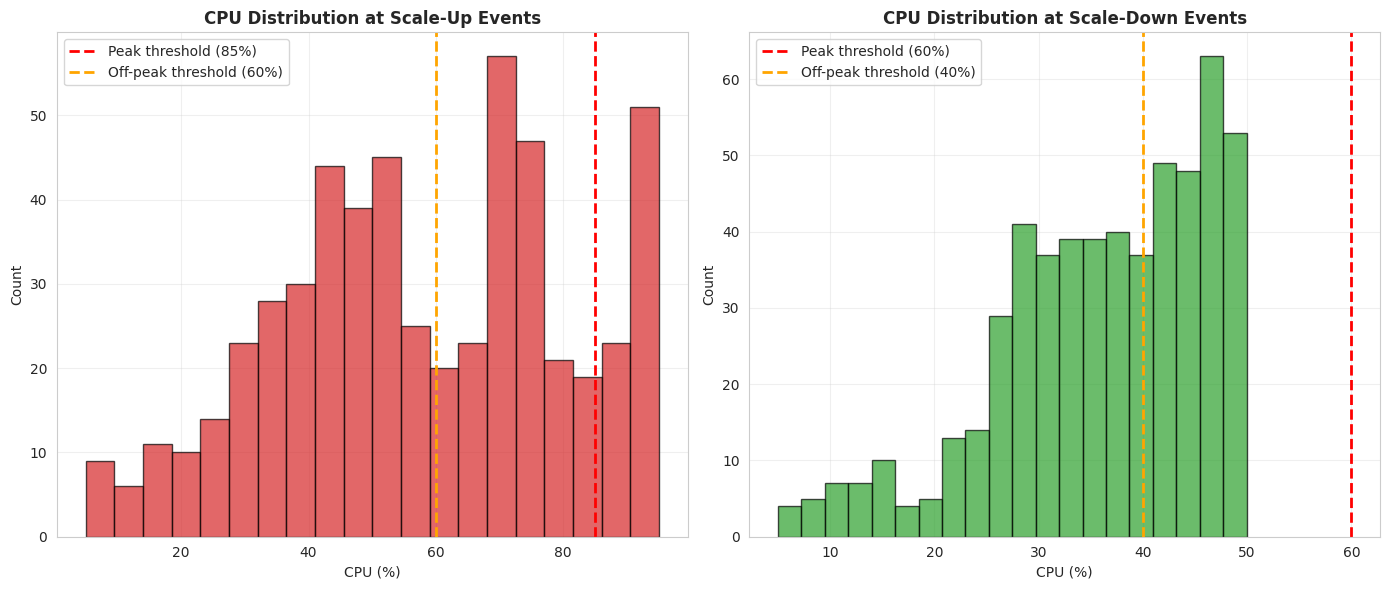


SCALING DECISION INSIGHTS
Total scale-up events: 545
Total scale-down events: 544

Average CPU at scale-up: 57.9%
Average pending pods at scale-up: 1.2


In [8]:
# Merge metrics with scaling decisions
history_df['hour'] = history_df['timestamp'].dt.hour

# Analyze conditions leading to scale-up
scale_ups = history_df[history_df['action'] == 'SCALE_UP'].copy()
scale_downs = history_df[history_df['action'] == 'SCALE_DOWN'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CPU distribution at scale-up
if len(scale_ups) > 0:
    axes[0].hist(scale_ups['cpu_percent'], bins=20, color='#d62728', alpha=0.7, edgecolor='black')
    axes[0].axvline(x=85, color='red', linestyle='--', linewidth=2, label='Peak threshold (85%)')
    axes[0].axvline(x=60, color='orange', linestyle='--', linewidth=2, label='Off-peak threshold (60%)')
    axes[0].set_title('CPU Distribution at Scale-Up Events', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('CPU (%)', fontsize=10)
    axes[0].set_ylabel('Count', fontsize=10)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No scale-up events recorded', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('CPU Distribution at Scale-Up Events', fontsize=12, fontweight='bold')

# CPU distribution at scale-down
if len(scale_downs) > 0:
    axes[1].hist(scale_downs['cpu_percent'], bins=20, color='#2ca02c', alpha=0.7, edgecolor='black')
    axes[1].axvline(x=60, color='red', linestyle='--', linewidth=2, label='Peak threshold (60%)')
    axes[1].axvline(x=40, color='orange', linestyle='--', linewidth=2, label='Off-peak threshold (40%)')
    axes[1].set_title('CPU Distribution at Scale-Down Events', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('CPU (%)', fontsize=10)
    axes[1].set_ylabel('Count', fontsize=10)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No scale-down events recorded', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('CPU Distribution at Scale-Down Events', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("SCALING DECISION INSIGHTS")
print("="*50)
print(f"Total scale-up events: {len(scale_ups)}")
print(f"Total scale-down events: {len(scale_downs)}")
if len(scale_ups) > 0:
    print(f"\nAverage CPU at scale-up: {scale_ups['cpu_percent'].mean():.1f}%")
    print(f"Average pending pods at scale-up: {scale_ups['pending_pods'].mean():.1f}")

## 6. Correlation Analysis

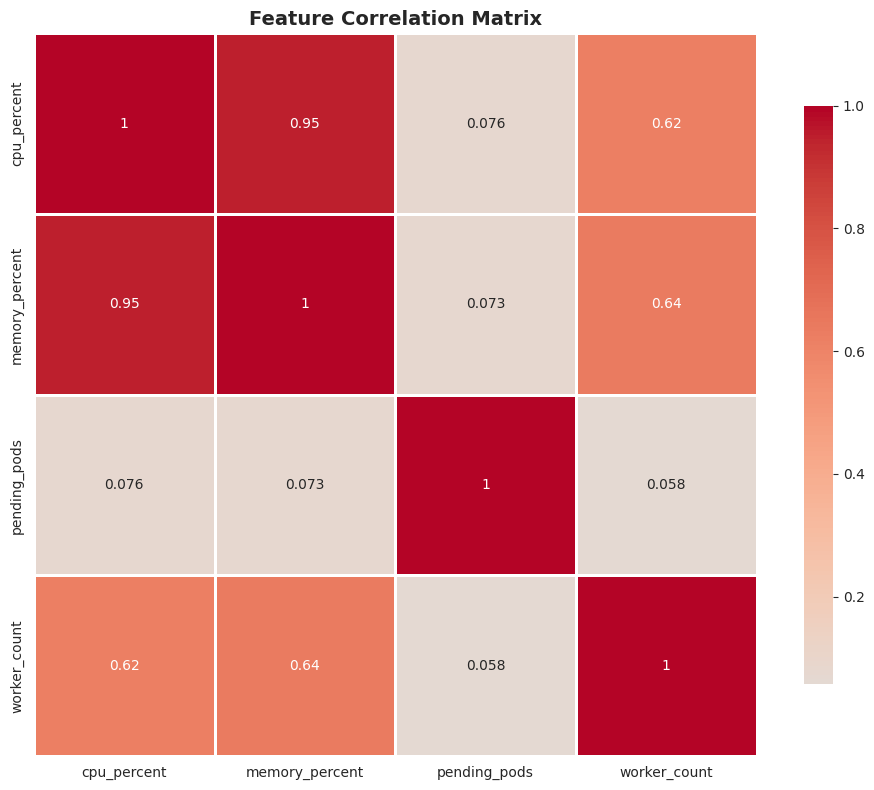


Key Correlations with CPU:
cpu_percent       1.000000
memory_percent    0.951062
worker_count      0.618824
pending_pods      0.075969
Name: cpu_percent, dtype: float64


In [9]:
# Compute correlation matrix
corr_cols = ['cpu_percent', 'memory_percent', 'pending_pods', 'worker_count']
correlation_matrix = metrics_df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Correlations with CPU:")
print(correlation_matrix['cpu_percent'].sort_values(ascending=False))

## 7. Predictability Assessment

**Question**: Is there enough pattern in the data for ML to learn?

We look for:
1. **Daily seasonality** - CPU peaks at certain hours
2. **Weekly seasonality** - Different patterns on weekdays vs weekends
3. **Autocorrelation** - Current CPU predicts future CPU
4. **Predictive features** - Pending pods correlate with future CPU spikes

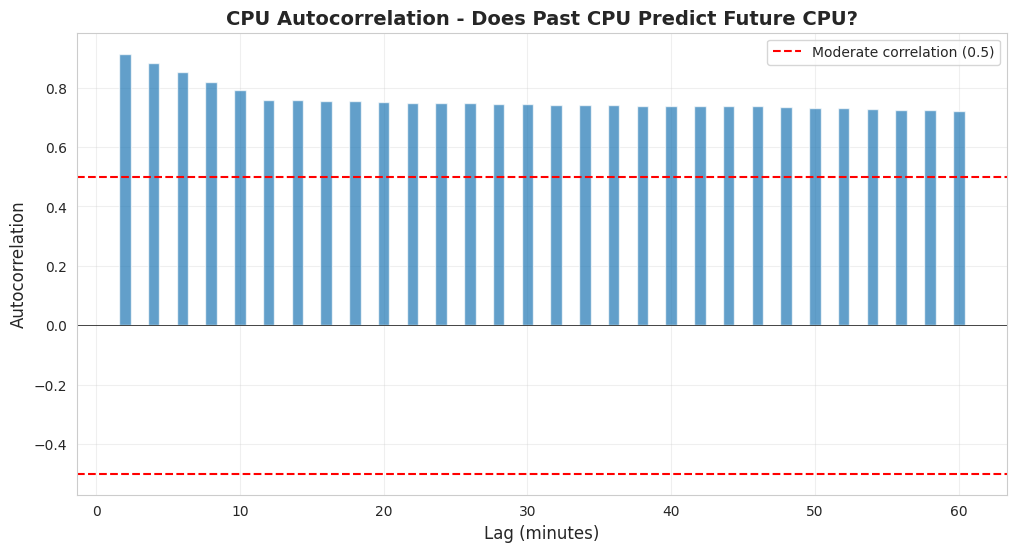


Lags with correlation > 0.5: 30
  2-minute lag: 0.914
  4-minute lag: 0.883
  6-minute lag: 0.852
  8-minute lag: 0.820
  10-minute lag: 0.791


In [10]:
# Lag analysis - does past CPU predict future CPU?
def compute_autocorrelation(series, max_lag=30):
    """Compute autocorrelation for given lags (in 2-min samples)."""
    autocorr = []
    for lag in range(1, max_lag + 1):
        # Convert to 2-min periods: lag * 2 minutes
        autocorr.append(series.autocorr(lag=lag))
    return autocorr

# Compute autocorrelation for CPU
max_lag_periods = 30  # 30 periods = 60 minutes at 2-min sample rate
cpu_autocorr = compute_autocorrelation(metrics_ts['cpu_percent'], max_lag=max_lag_periods)

# Plot autocorrelation
lags_minutes = [lag * 2 for lag in range(1, max_lag_periods + 1)]  # Convert to minutes

plt.figure(figsize=(12, 6))
plt.bar(lags_minutes, cpu_autocorr, color='#1f77b4', alpha=0.7)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.axhline(y=0.5, color='red', linestyle='--', label='Moderate correlation (0.5)')
plt.axhline(y=-0.5, color='red', linestyle='--')
plt.xlabel('Lag (minutes)', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)
plt.title('CPU Autocorrelation - Does Past CPU Predict Future CPU?', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find significant lags
significant_lags = [(i+1, corr) for i, corr in enumerate(cpu_autocorr) if abs(corr) > 0.5]
print(f"\nLags with correlation > 0.5: {len(significant_lags)}")
if significant_lags:
    for lag, corr in significant_lags[:5]:  # Show top 5
        print(f"  {lag*2}-minute lag: {corr:.3f}")

## 8. Conclusion - Is ML Worth Pursuing?

Based on the analysis above, we can determine:

| Signal | Found | ML Impact |
|--------|-------|------------|
| Daily seasonality | ☐ | High - Prophet handles this well |
| Weekly seasonality | ☐ | Medium - Weekday vs weekend patterns |
| Autocorrelation | ☐ | High - Past CPU predicts future |
| Pending pods → CPU | ☐ | Medium - Leading indicator |

**Recommendation:**
- If 3+ signals found → **ML is worth pursuing**
- If 1-2 signals found → **ML may help, but simple rules may suffice**
- If 0 signals found → **Too noisy, collect more data**